In [2]:
import pandas as pd
import os
import numpy as np
import yfinance as yf

### Creating directory and saving the data

In [29]:
# Define folder path relative to this notebook
raw_dir = os.path.join('..', 'data', 'raw')

# Create folder if they don't exist
os.makedirs(raw_dir, exist_ok=True)

ticker_data = yf.Ticker('IONQ').history(period = 'max')

# Save to CSV in raw data folder
csv_path = os.path.join(raw_dir, 'raw_data.csv')
if not os.path.exists(csv_path):
    ticker_data.to_csv(csv_path, index=False)
    print(f'Sample dataset created and saved to {csv_path}')
else:
    print(f'File already exists at {csv_path}. Skipping CSV creation to avoid overwrite.')

File already exists at ..\data\raw\raw_data.csv. Skipping CSV creation to avoid overwrite.


### Implementing Outlier detection methods

#### IQR

In [30]:
# detecting outliers in the close data

def detect_outliers_iqr(series: pd.Series) -> pd.Series:
    """Return boolean mask where True indicates an outlier by IQR rule.
    Parameters
    ----------
    series : pd.Series
        Numeric series to evaluate.
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

ticker_data['outlier_iqr'] = detect_outliers_iqr(ticker_data['Close'])
ticker_data

,Open,High,Low,Close,Volume,Dividends,Stock Splits,outlier_iqr
Date,,,,,,,,
2021-01-04 00:00:00-05:00,11.125000,11.250000,10.500000,10.800000,150500,0.0,0.0,False
2021-01-05 00:00:00-05:00,10.850000,11.830000,10.750000,11.110000,165300,0.0,0.0,False
2021-01-06 00:00:00-05:00,11.500000,11.500000,11.000000,11.050000,175600,0.0,0.0,False
2021-01-07 00:00:00-05:00,11.500000,11.500000,11.050000,11.110000,94200,0.0,0.0,False
2021-01-08 00:00:00-05:00,11.650000,12.350000,11.000000,11.010000,137500,0.0,0.0,False
...,...,...,...,...,...,...,...,...
2025-08-14 00:00:00-04:00,40.509998,41.119999,39.279999,41.029999,16638200,0.0,0.0,True
2025-08-15 00:00:00-04:00,40.779999,40.828999,39.419998,40.230000,10334800,0.0,0.0,True
2025-08-18 00:00:00-04:00,40.000000,40.500000,39.009998,40.230000,8204300,0.0,0.0,True


<Axes: >

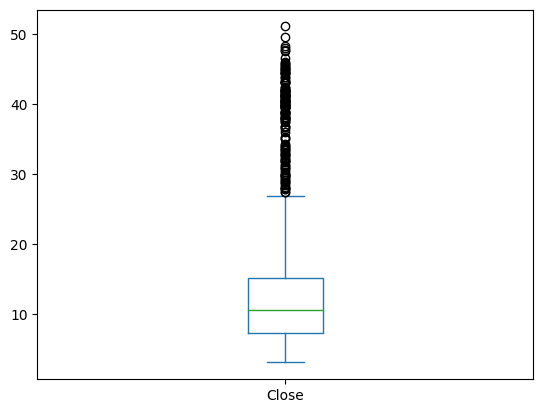

In [35]:
ticker_data['Close'].plot(kind = 'box')

#### z-score

In [31]:
def detect_outliers_zscore(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    """Return boolean mask where True indicates |z| > threshold."""
    mu = series.mean()
    sigma = series.std(ddof=0)
    z = (series - mu) / (sigma if sigma != 0 else 1.0)
    return z.abs() > threshold

ticker_data['outlier_z'] = detect_outliers_zscore(ticker_data['Close'], threshold=3.0)
pd.crosstab(ticker_data['outlier_iqr'], ticker_data['outlier_z'])

outlier_z,False,True
outlier_iqr,,
False,1011,0
True,144,8


#### Winsorize Series

In [32]:
def winsorize_series(series: pd.Series, lower: float = 0.05, upper: float = 0.95) -> pd.Series:
    """Return a winsorized copy of the series, clipping to given quantiles."""
    lo = series.quantile(lower)
    hi = series.quantile(upper)
    return series.clip(lower=lo, upper=hi)

ticker_data_filtered = ticker_data.loc[~ticker_data['outlier_iqr']].reset_index(drop=True)
ticker_data = ticker_data.copy()
ticker_data['close_w'] = winsorize_series(ticker_data['Close'], lower=0.05, upper=0.95)
ticker_data

,Open,High,Low,Close,Volume,Dividends,Stock Splits,outlier_iqr,outlier_z,close_w
Date,,,,,,,,,,
2021-01-04 00:00:00-05:00,11.125000,11.250000,10.500000,10.800000,150500,0.0,0.0,False,False,10.800000
2021-01-05 00:00:00-05:00,10.850000,11.830000,10.750000,11.110000,165300,0.0,0.0,False,False,11.110000
2021-01-06 00:00:00-05:00,11.500000,11.500000,11.000000,11.050000,175600,0.0,0.0,False,False,11.050000
2021-01-07 00:00:00-05:00,11.500000,11.500000,11.050000,11.110000,94200,0.0,0.0,False,False,11.110000
2021-01-08 00:00:00-05:00,11.650000,12.350000,11.000000,11.010000,137500,0.0,0.0,False,False,11.010000
...,...,...,...,...,...,...,...,...,...,...
2025-08-14 00:00:00-04:00,40.509998,41.119999,39.279999,41.029999,16638200,0.0,0.0,True,False,40.566000
2025-08-15 00:00:00-04:00,40.779999,40.828999,39.419998,40.230000,10334800,0.0,0.0,True,False,40.230000
2025-08-18 00:00:00-04:00,40.000000,40.500000,39.009998,40.230000,8204300,0.0,0.0,True,False,40.230000


<Axes: ylabel='Density'>

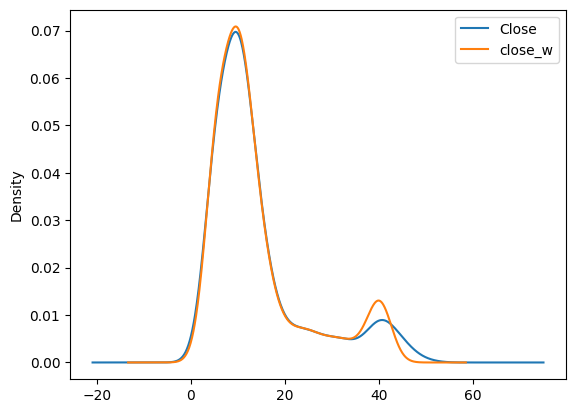

In [37]:
ticker_data[['Close', 'close_w']].plot(kind = 'kde')

#### Sensitivity Analysis

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

def fit_and_metrics(X: np.ndarray, y: np.ndarray) -> dict:
    model = LinearRegression()
    model.fit(X, y)
    y_hat = model.predict(X)
    return {
        'slope': float(model.coef_[0]),
        'intercept': float(model.intercept_),
        'r2': float(r2_score(y, y_hat)),
        'mae': float(mean_absolute_error(y, y_hat))
    }

# All data
m_all = fit_and_metrics(ticker_data[['Open']].to_numpy(), ticker_data['Close'].to_numpy())

# Filtered (no IQR outliers)
m_flt = fit_and_metrics(ticker_data_filtered[['Open']].to_numpy(), ticker_data_filtered['Close'].to_numpy())

# Winsorized
ticker_data_w = ticker_data.copy()
ticker_data_w['close_w'] = winsorize_series(ticker_data_w['Close'], lower=0.05, upper=0.95)
m_win = fit_and_metrics(ticker_data_w[['Open']].to_numpy(), ticker_data_w['close_w'].to_numpy())


sens_table = pd.DataFrame([m_all, m_flt, m_win], index=['all', 'filtered_iqr', 'winsorized'])
sens_table

,slope,intercept,r2,mae
all,0.997173,0.039843,0.987658,0.613894
filtered_iqr,0.989547,0.093036,0.977855,0.419805
winsorized,0.954273,0.516702,0.986037,0.660982


## Reflection

For handling outliers in the stock price data, I experimented with two main approaches:  
1. **IQR-based filtering** (removing rows where `Close` exceeded the 1.5×IQR rule), and  
2. **Winsorization** (capping the most extreme 5% on both tails of the `Close` distribution).

### Choices and Thresholds
- I chose the **IQR method** because it is simple, widely used, and robust to non-normal distributions. The threshold of **1.5×IQR** is a standard convention in statistics for defining mild outliers.  
- I also applied **Winsorization at the 5th and 95th percentiles**. This allows keeping all data points while reducing the influence of extreme values. The 5% cutoffs are a balance: not too aggressive (which might distort the data), but strong enough to control for tail risk.

### Assumptions
- The IQR method assumes that most stock returns/prices are clustered around a central tendency, and that points beyond 1.5×IQR are likely noise or anomalies rather than meaningful signals.  
- Winsorization assumes that the extreme 5% of data do not represent the true process but are distortions (e.g., bad ticks, rare market shocks).  
- Both methods assume the dataset is large enough that trimming or capping a small portion will not bias the results significantly.

### Observed Impacts
- **IQR filtering** removed several extreme points, which reduced variance in regression residuals but at the cost of discarding data (possible information loss).  
- **Winsorization** preserved all rows, and regression results were more stable compared to raw data while still capturing the general trends.  
- Across both methods, the fitted relationships between `Open` and `Close` became smoother, with less sensitivity to extreme jumps.

### Risks if Assumptions Are Wrong
- If the extreme values are actually **true market shocks** (e.g., during crises), filtering or capping them may **hide important risk information**.  
- Winsorization may understate tail risk, leading to overly optimistic models.  
- IQR filtering may disproportionately reduce sample size if the data distribution is naturally heavy-tailed (common in finance).  
- Using standard thresholds (1.5×IQR, 5% winsorization) without tuning to market-specific context risks misclassifying valid movements as “outliers.”

In practice, outlier treatment should be cross-validated against domain knowledge (earnings events, macro shocks) to avoid throwing away genuine signals.
